In [5]:
%load_ext autoreload
%autoreload 2

import os

from functools import partial

if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"

import blackjax
import bayesflow as bf
import jax
import jax.numpy as jnp
import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from jax.scipy import stats

from approximator import LikelihoodApproximator
from priors import truncated_normal_rvs
from mcmc import model_nle, warmup, inference_loop_multiple_chains
from plots import create_profile_likelihood_plot, create_pushforward_plot_rdmc
from rdmc import rdmc_single_accumulator, rdmc_prior_single
from density import rdmc_approx_likelihood, get_pdf

jax.config.update("jax_enable_x64", True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
def simulator_fun(**kwargs):
    return rdmc_single_accumulator(**kwargs, t_max=5000, a_shape=2)


def meta(batch_size):
    num_obs = 500 # np.random.default_rng(2025).integers(250, 750)

    return dict(num_obs=num_obs)

simulator = bf.simulators.make_simulator([rdmc_prior_single, simulator_fun], meta_fn=meta)

In [7]:
param_names = ["v_c", "tau", "amp", "s", "b", "t0"]

test_data = simulator.sample(500)
# test_data["x"][..., 0] *= 1000
prior_draws = np.array([test_data[p] for p in param_names]).squeeze()

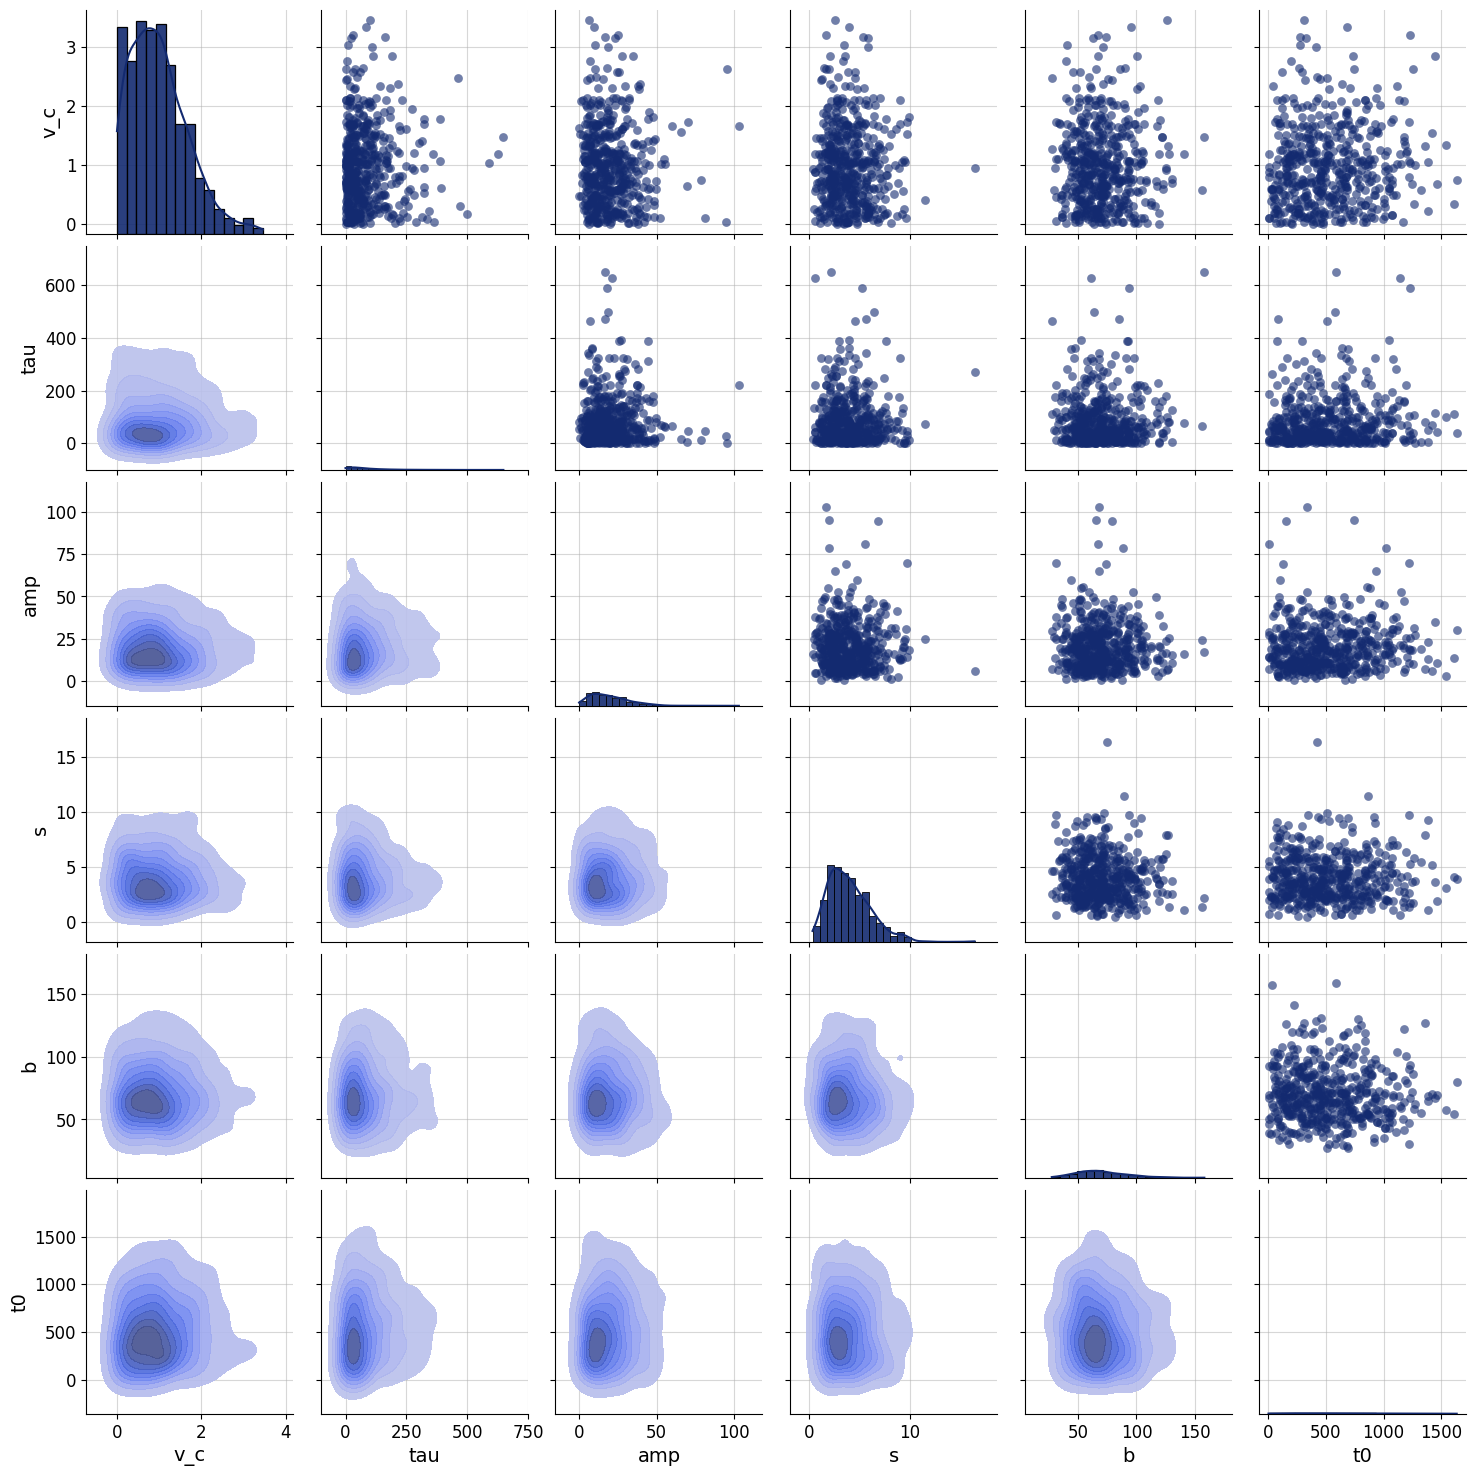

In [8]:
bf.diagnostics.plots.pairs_samples(test_data, variable_keys=param_names)

In [9]:
def create_pushforward_plot_rdm(data, prior_samples, param_names=None):
    fig, axarr = plt.subplots(5, 5, figsize=(12, 12))
    for i, ax in enumerate(axarr.flat):
        rt = data[i, :].flatten()
        params = prior_samples[:, i]
        print(params.shape)
        sns.histplot(
            rt, color="darkgreen", alpha=0.5, ax=ax
        )
        sns.despine(ax=ax)
        
        for i, p in enumerate(params):
            if param_names is not None:
                ps = param_names[i] + ": " + str(np.round(p, 3))
            else:
                ps = np.round(p, 2)
            ax.text(
                0.9,
                0.8 - i * 0.1,
                ps,
                horizontalalignment="center",
                verticalalignment="center",
                transform=ax.transAxes,
            )

        # ax.legend(labels=["False", "True"])
        ax.set_ylabel("")
        ax.set_yticks([])
        if i > 19:
            ax.set_xlabel("Simulated RTs (seconds)")
    fig.tight_layout()
    return fig

(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)
(6,)


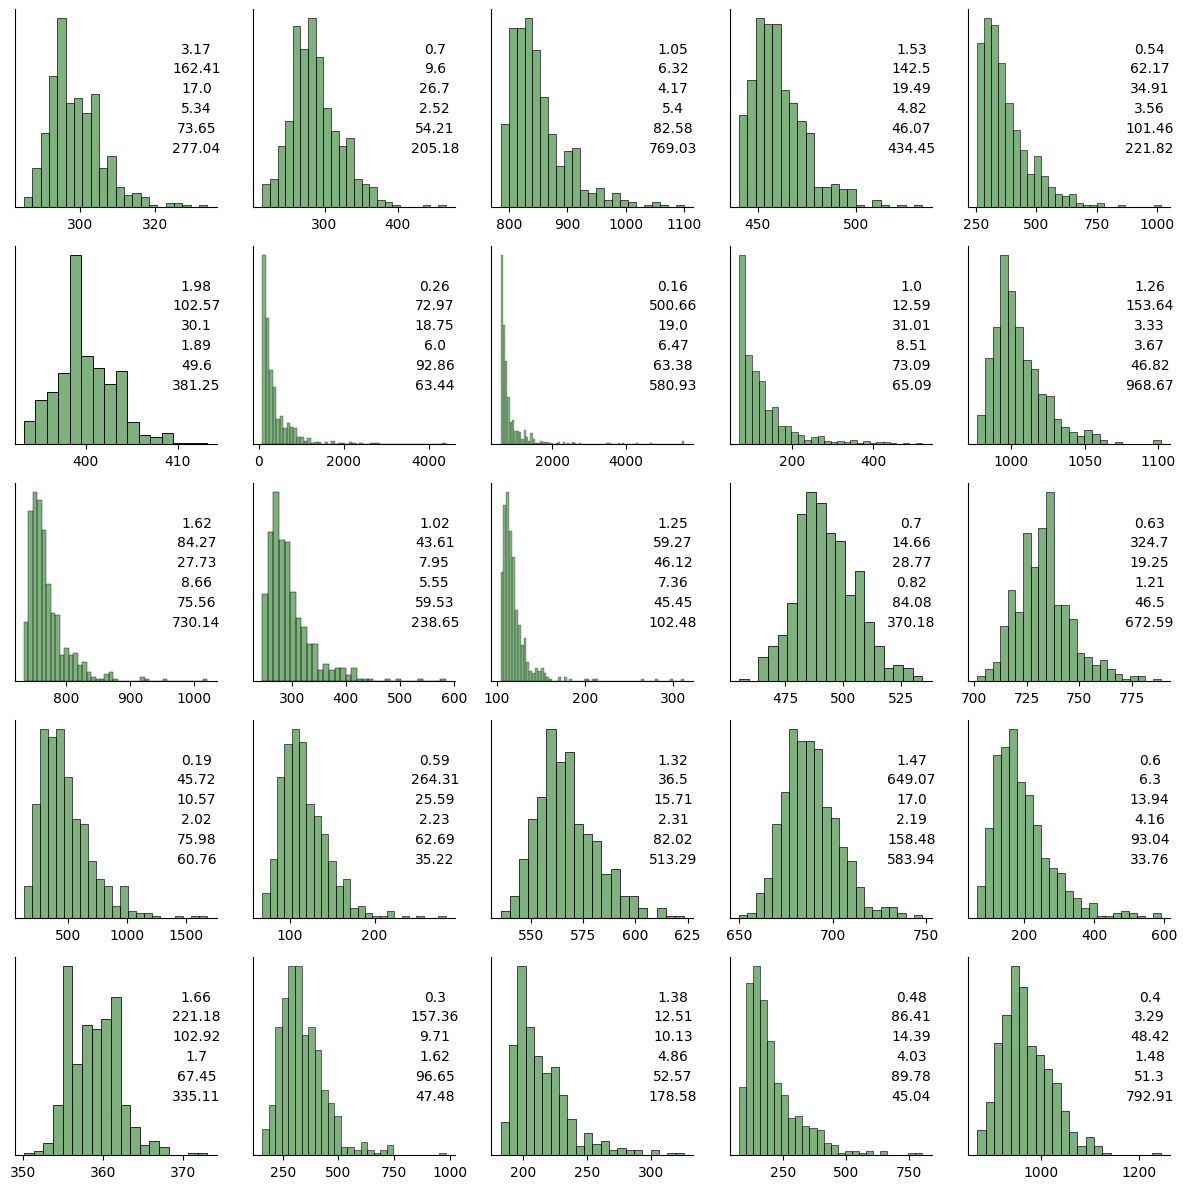

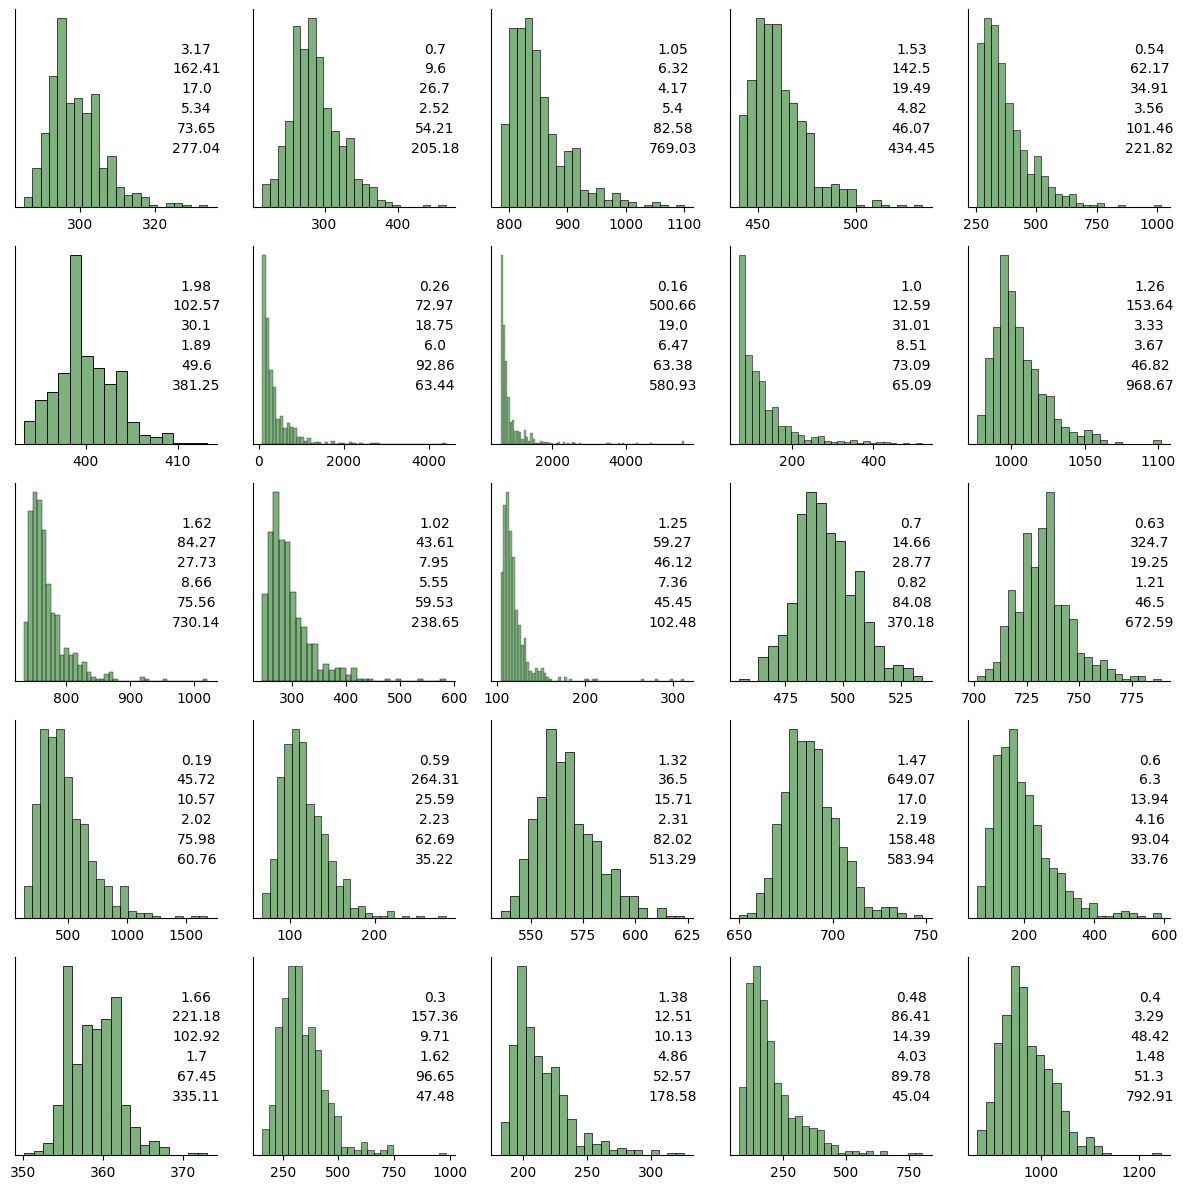

In [10]:
create_pushforward_plot_rdm(test_data["x"], prior_draws)